# Домашнее задание № 1

Вам необходимо провести анализ и подготовить данные.

# Исходные данные

Ознакомьтесь с данными в [источнике](https://www.kaggle.com/uciml/student-alcohol-consumption?select=student-por.csv):

Если вкратце, то у вас есть 29 параметров и одна целевая переменная G3.

In [142]:
import pandas as pd
import plotly.express as px
import numpy as np

In [2]:
# Читаем данные

X_train = pd.read_csv('train_features_with_answers.csv')

In [4]:
# Про характеристики прочитайте в источнике

X_train.sample(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3
68,GP,M,161.0,U,GT3,T,3,3,services,other,...,yes,yes,4,2,3,1,2,3,0,13
116,GP,F,16.0,U,GT3,T,3,3,other,other,...,no,no,5,3,2,1,1,4,2,14
101,GP,F,18.0,U,GT3,T,2,1,services,other,...,yes,no,5,3,3,1,2,1,2,15
29,GP,M,18.0,U,GT3,T,4,4,other,other,...,yes,no,4,3,3,2,2,3,0,13
37,GP,M,16.0,U,GT3,T,3,3,other,services,...,yes,no,5,4,2,1,1,5,6,15


# Часть 1. Визуальный анализ данных (Exploratory Data Analysis)

Перед тем, как приступать к построению алгоритмов, необходимо понять данные, с которыми требуется работать. Для этого в подходах к построению алгоритмов машинного обучения выделят специальный этап - Разведочный анализ данных или Exploratory Data Analysis (EDA). EDA в себя включает все те, что касается описания данных: визуализацию, интерпретацию и анализ.

Прежде всего сделаем визуализацию данных для того, чтобы оценить диапазоны значений и виды их распределений.

Постройте для приведенных ниже характеристик следующие виды графиков:
- Гистограммы;
- Круговые диаграмм;
- Графики;
- Таблицы;
- 3D диаграммы.

Выберите наиболее подходящий тип графика для каждой характеристки.

__Основной критерий оценивания__ - читаемость и интерпретируемость данных.

In [6]:
df = X_train

## Характеристика: "Sex"

<Axes: >

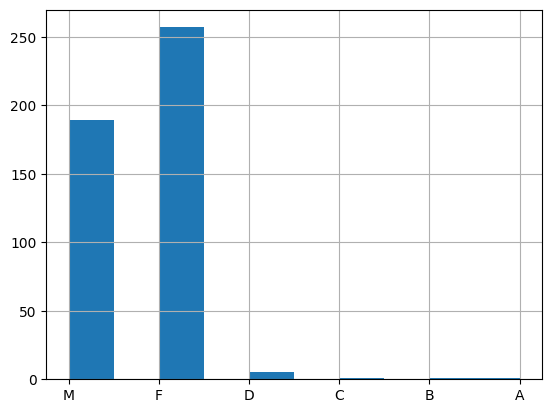

In [15]:
df['sex'].hist()

## Характеристика: "Age"

<Axes: >

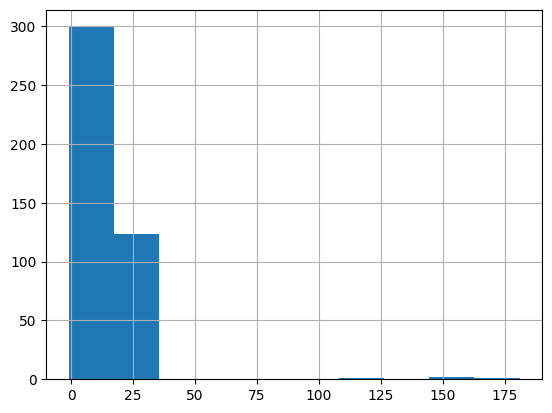

In [23]:
df['age'].hist()

## Характеристика: "Weekly study time"

<Axes: >

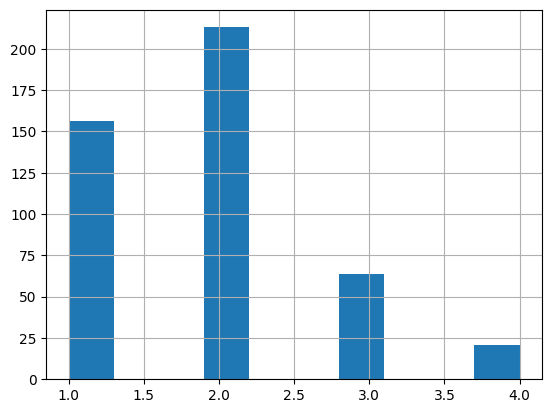

In [24]:
df['studytime'].hist()

## Характеристика: "Romantic Relationship"

In [53]:
df['romantic'].value_counts(normalize=True)

romantic
no     0.636564
yes    0.363436
Name: proportion, dtype: float64

## Характеристика: "Alcohol Consumption"

<Axes: >

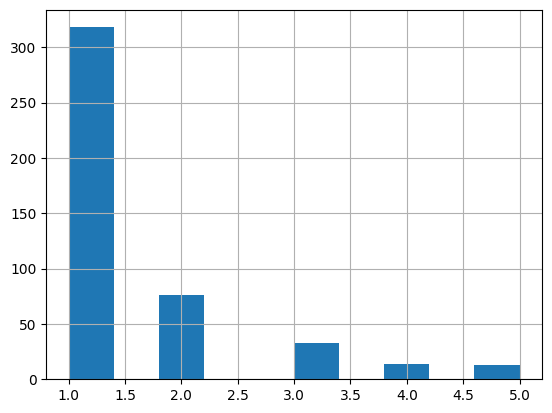

In [59]:
df['Dalc'].hist()

<Axes: >

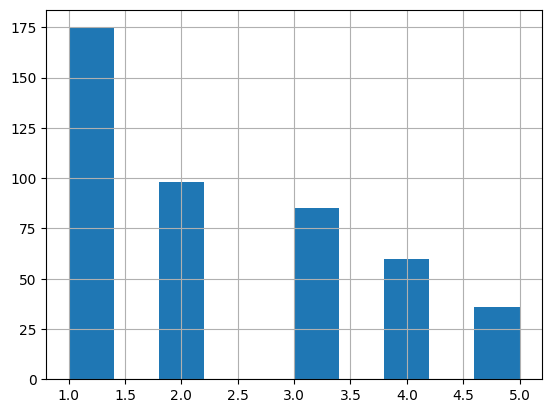

In [60]:
df['Walc'].hist()

## Целевая зависимость: "G3" (Final Grade)

<Axes: >

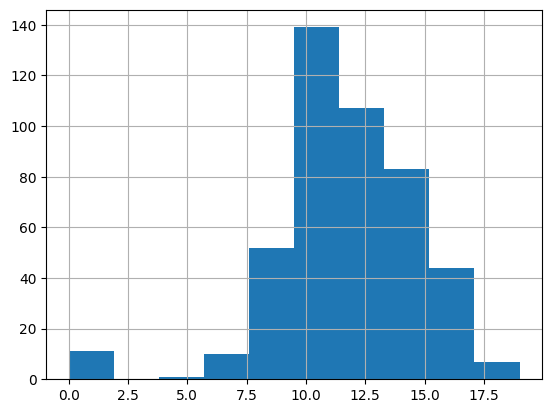

In [65]:
df['G3'].hist()

## Прочие характеристики

Прочитайте описание данных на [сайте](https://www.kaggle.com/uciml/student-alcohol-consumption) и подумайте, какие еще характеристики было бы полезно проанализировать. Постройте соответсвующие графики для выбранных характеристик.

Постройте графики еще для минимум 4 характеристик: числовая (2) и категориальная (2), применив хотя бы один раз:
- pieplot
- boxplot
- violinplot

## Корреляция признаков

Для того, чтобы быстро получить оценку о взаимосвязи признаков целесообразно построить матрицу их корреляции. Постройте матрицу корреляции.

In [73]:
numeric = df.select_dtypes(include=['float64', 'int64']).columns

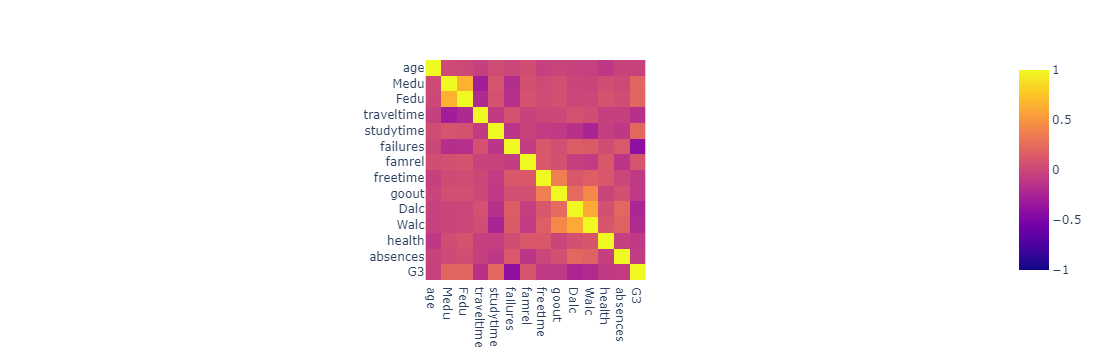

In [86]:
px.imshow(df.corr(numeric_only=True) , range_color=[-1,1])

## Посчитайте корреляцию Спирмана и нарисуйте ее в виде тепловой карты

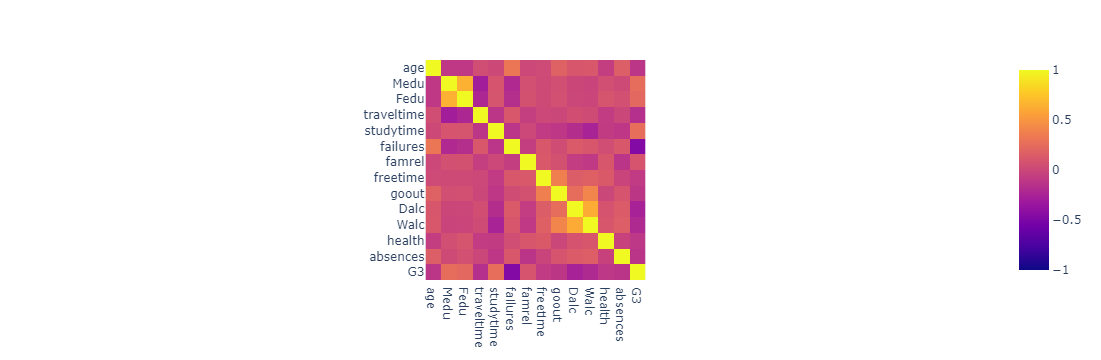

In [98]:
px.imshow(df.corr(numeric_only=True, method='spearman', min_periods=5), range_color=[-1,1])

## Диапазон значений характеристик

Посчитайте число уникальных значений для каждого признака и сравните их между собой.

In [104]:
values = {col : len(df[col].unique()) for col in df.columns}

In [106]:
values

{'school': 2,
 'sex': 6,
 'age': 17,
 'address': 3,
 'famsize': 2,
 'Pstatus': 2,
 'Medu': 5,
 'Fedu': 5,
 'Mjob': 5,
 'Fjob': 5,
 'reason': 4,
 'guardian': 3,
 'traveltime': 4,
 'studytime': 4,
 'failures': 4,
 'schoolsup': 2,
 'famsup': 2,
 'paid': 2,
 'activities': 2,
 'nursery': 2,
 'higher': 2,
 'internet': 2,
 'romantic': 2,
 'famrel': 5,
 'freetime': 5,
 'goout': 5,
 'Dalc': 5,
 'Walc': 5,
 'health': 5,
 'absences': 22,
 'G3': 17}

## Найдите соотношение мужского и женского пола для самых выскоих оценок (G3) из датасета, у которых время на дорогу больше, чем 30 минут. Нарисуйте это соотношение на круговой диаграмме

In [179]:
marks = df['G3'].unique() 
marks = marks[marks > marks.max() * 0.8]
marks

array([16, 17, 19, 18], dtype=int64)

In [200]:
df_mf = df[(df['sex'].isin(['F', 'M'])) & (df['G3'] >= 16)]

<Axes: ylabel='traveltime'>

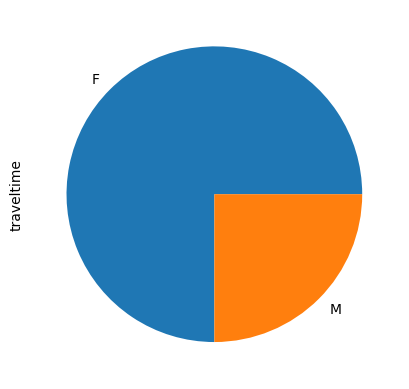

In [212]:
df_mf[df_mf['traveltime'] >= 3].groupby('sex')['traveltime'].count().plot.pie()

## Построить boxplot для оценок по возрасту.  

## Найти id топ-5 самых юных отличников.

## Для каждого возраста найдите максимальную и минимальную оценку (G3)

# Часть 2. Предобработка данных

Теперь перейдем к подготовке данных для моделей машинного обучения. Не все из описанного ниже нужно делать. Подумайте.

## Найдите и исправьте ошибки в данных

## Удалите скоррелированные данные

## Заполните пропуски в данных

Заполнить пропуски в данных можно одним из следующи способов или разными для разных признаков:
- Заполнить нулями
- Выбросить данные с нулями (не рекомендуется)
- Заполнить средним для данного параметра
- Заполнить наиболее соответствующим данному прецеденту (рекомендуется)

## Закодируйте категориальные признаки

## Придумайте сложные признаки

Сложные признаки - это комбинации существующих (линейных или нелинейных).
Это нужно для того, чтобы самостоятельно добавить нелинейность в алгоритм.

Приведите не менее двух признаков.

# Часть 3. Стратегия валидации

Итак, у вас есть данные для обучения и данные, на которых необходимо сделать предсказание. Для оценки точности необходимо проводить валидацию (так как мало данных, можно проводить кросс валидацию).
Валидацию проще всего реализовать методами sklearn, например:
- KFold
- ShuffleSplit
- StratifiedKFold
- StratifiedShuffleSplit
- GroupKFold
- GroupShuffleSplit

In [ ]:
# Ваш код

## Разделите данные и объясните выбор стратегии

In [ ]:
# Ваш код

__Ваш ответ:__ ...

# Часть 4. Заполнение пропусков в данных

## Фильтрация по диапазону значений

Проверьте, что все характеристики принадлежат тому диапазону значений, который приведен в описании к исходным данным. Например, если в графе "Пол" есть значение FF, P или -1, то это явная ошибка заполнения.

Приведите данные в соответствии с описанием данных. Если значение указано неверно - укажите ```NaN```.

In [ ]:
# Ваш код

## Адаптивное заполнения пропусков

Реализуйте стратегию заполнения пропусков данных на основе схожих примеров. Обучите один из известных вам алгоритмов (knn, Naive Bayes, linear regression) для предсказания той характеристики, пропуски которой присутсвуют в данных. В качестве характеристики для обучения алгоритмов __нельзя__ использовать ```G3```.

In [ ]:
# Ваш код

# Часть 5. Обучение алгоритма

Целевая переменная принимает дискретные значения [0; 20], поэтому вы можете поставить как задачу классификации, так и задачу регрессии.

!Не забудьте про оптимизацию параметров алгоритмов, у вас же уже есть данные для валидации.

## KNN

## Bayes

## Регрессия

## SVM

## Постройте сложную модель на основе предыдущих четырех простых и оцените ее точность

Вариант 1. Нужно взвесить предсказания простых моделей. Предложите метод взвешивания.

Вариант 2. Нужно оценить корреляцию предсказаний простых моделей.

## Сделайте итоговое предсказание

Решением домашнего задания является данный ноутбук + .csv файл с предсказанием. Пример формата файла, который должен у вас получится приведен в ```data/sample_submission.csv```. Данные для предсказания - ```X_test.csv```.

За лучшее предсказание 5 человек получат +10% к домашке.

Значения предсказаний должны быть целочисленными. Проверка будет точности решения будет по MSE.

In [ ]:
# Для jupyter notebook

submission = pd.read_csv('data/sample_submission.csv', index_col='id')
submission['G3'] = 1 # ваше предсказание
submission.to_csv('data/submission.csv', index=False)

In [ ]:
# Для colab notebook

from google.colab import files

pd.read_csv('data/sample_submission.csv', index_col='id')
submission['G3'] = 1 # ваше предсказание
submission.to_csv('data/submission.csv', index=False)
files.download('data/submission.csv')

# Часть 6. Состязательная валидация (Adversarial Validation)

Данная стратегия часто применяется в соревнованиях по машинному обучению. Так как проверить свой алгоритм возможно только на заданном тренировочном наборе данных, а результат требуется к набору, для которого нет ответов, то выбирают следующий подход:
- оценить степень схожести тренировочных и тестовых данных;
- составить валидацию из тех тренировочных данных, которые больше похожи на тестовые.

Алгоритм реализации AV:
1. Удаляем ответы из тренировочных данных.
2. Добавляем специальные метки (```is_test```) для классов: тренировочные данные и тестовые.
То есть у тестовых данных будет значение ```is_test = 1```, а у тренировочных ```is_test = 0```.
4. Учим алгоритм классификации предсказывать заданную метку ```is_test```.
5. Делим тренировочные данные на N частей и проводим кросс-валидацию.

Обучаем N алгоритмов классификации: каждый обучается на всех тестовых данных и на N-1 наборах тренировочных. Предсказываем на 1 тренировочном наборе.

6. Для каждого элемента в выборке предсказываем вероятность принадлежности класса и сортируем тренировочные данные по вероятности принадлежности тестовой выборке.
7. Выделяем заданное число данных в валидацию.
8. Обучаемся для итогового предсказания на всех данных.